# Notebook 03 — Analyse Exploratoire des Données (EDA)
**Projet : Gestion des ventes et prévision des sorties de stock**

Ce notebook réalise une analyse exploratoire complète de la base d'apprentissage
(`base_apprentissage_ml.csv`) produite par le notebook 02.

### Objectifs de l'EDA
| Étape | Objectif |
|---|---|
| 1. Vue d'ensemble | Vérifier les dimensions, types et valeurs manquantes |
| 2. Statistiques descriptives | Comprendre la distribution de chaque variable |
| 3. Variable cible | Analyser `quantite_vendue` (distribution, asymétrie) |
| 4. Variables numériques | Distributions, outliers, skewness |
| 5. Variable catégorielle | Répartition par `categorie`, impact sur la cible |
| 6. Corrélations | Matrice de corrélation, liens avec la cible |
| 7. Analyse temporelle | Évolution des ventes dans le temps |
| 8. Bilan EDA | Décisions pour la modélisation (notebook 04) |

---

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Options d'affichage ──────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Style global des graphiques ──────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

# ── Palette catégorielle cohérente sur tout le notebook ──────────────────
PALETTE_CAT = {
    'Electromenager'          : '#4C72B0',
    'Groupe electrogene'      : '#DD8452',
    'Instrument de musique'   : '#55A868',
    'Smartphone'              : '#C44E52',
}

FICHIER = 'base_apprentissage_ml.csv'
print('Librairies chargées ✓')

Librairies chargées ✓


---
## 1. Vue d'ensemble de la base

On commence par vérifier les dimensions, les types de données et la présence
éventuelle de valeurs manquantes — héritage direct des jointures du notebook 02.

In [2]:
df = pd.read_csv(FICHIER)
df['date'] = pd.to_datetime(df['date'])

print(f'Dimensions       : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Période couverte : {df["date"].min().date()}  →  {df["date"].max().date()}')
print()
print('── Aperçu des 5 premières lignes ──────────────────────────────────')
display(df.head())

Dimensions       : 900 lignes × 9 colonnes
Période couverte : 2025-01-01  →  2026-03-20

── Aperçu des 5 premières lignes ──────────────────────────────────


,date,reference,designation,prix_unitaire,categorie,quantite_entree,stock_actuel,seuil_d_alerte,quantite_vendue
0,2025-01-01,MUS-0094,Piano numerique 094,"1,456,997.89",Instrument de musique,56,355,13,37
1,2025-01-02,ELM-0071,Lave-linge 071,"272,779.92",Electromenager,150,105,15,59
2,2025-01-02,SMP-0065,Smartphone Ultra 065,"307,551.03",Smartphone,195,482,8,1
3,2025-01-02,SMP-0047,Smartphone Lite 047,"328,380.93",Smartphone,29,0,18,17
4,2025-01-02,MUS-0009,Clavier arrangeur 009,"2,081,845.57",Instrument de musique,389,493,18,23


In [3]:
# ── Types et valeurs manquantes ─────────────────────────────────────────
info = pd.DataFrame({
    'Type'            : df.dtypes,
    'Non-nuls'        : df.notna().sum(),
    'Valeurs manquantes' : df.isna().sum(),
    '% manquant'      : (df.isna().mean() * 100).round(2),
})
print('── Informations sur les colonnes ──────────────────────────────────')
display(info)

── Informations sur les colonnes ──────────────────────────────────


,Type,Non-nuls,Valeurs manquantes,% manquant
date,datetime64[ns],900,0,0.00
reference,object,900,0,0.00
designation,object,900,0,0.00
prix_unitaire,float64,900,0,0.00
categorie,object,900,0,0.00
quantite_entree,int64,900,0,0.00
stock_actuel,int64,900,0,0.00
seuil_d_alerte,int64,900,0,0.00
quantite_vendue,int64,900,0,0.00


In [4]:
# ── Vérification des doublons ───────────────────────────────────────────
n_doublons = df.duplicated().sum()
print(f'Lignes dupliquées : {n_doublons}')
if n_doublons == 0:
    print('→ Aucun doublon détecté ✓')
else:
    print('→ Attention : des doublons sont présents — à investiguer avant modélisation')

Lignes dupliquées : 0
→ Aucun doublon détecté ✓


---
## 2. Statistiques descriptives

`describe()` donne un premier aperçu des ordres de grandeur et des plages de variation.

In [5]:
VARS_NUM = ['prix_unitaire', 'quantite_entree', 'stock_actuel',
            'seuil_d_alerte', 'quantite_vendue']

desc = df[VARS_NUM].describe().T
desc['cv_%'] = (desc['std'] / desc['mean'] * 100).round(1)  # Coefficient de variation
print('── Statistiques descriptives des variables numériques ─────────────')
display(desc.round(2))


── Statistiques descriptives des variables numériques ─────────────


,count,mean,std,min,25%,50%,75%,max,cv_%
prix_unitaire,900.00,"1,218,797.35","935,030.22","60,892.92","509,670.58","997,737.94","1,557,695.71","4,231,088.80",76.70
quantite_entree,900.00,94.48,85.70,0.00,20.75,80.50,150.00,485.00,90.70
stock_actuel,900.00,183.41,135.36,0.00,73.00,168.00,278.00,629.00,73.80
seuil_d_alerte,900.00,14.54,6.55,3.00,9.00,14.00,20.00,25.00,45.00
quantite_vendue,900.00,39.83,22.93,1.00,20.00,38.00,60.00,80.00,57.60


> **Lecture rapide :**
> - `prix_unitaire` varie de 60 893 à 4 231 089 Ar — amplitude très large, coefficient de variation élevé (> 75 %).
> - `quantite_vendue` (notre cible Y) est bornée entre 1 et 80 — distribution relativement homogène.
> - `quantite_entree` présente un écart-type important par rapport à la moyenne (cv > 90 %) — queue de distribution à droite probable.

---
## 3. Analyse de la variable cible — `quantite_vendue`

La variable cible est ce que nos modèles de régression (Régression Linéaire et KNN)
vont chercher à prédire. Il est essentiel de comprendre sa distribution.

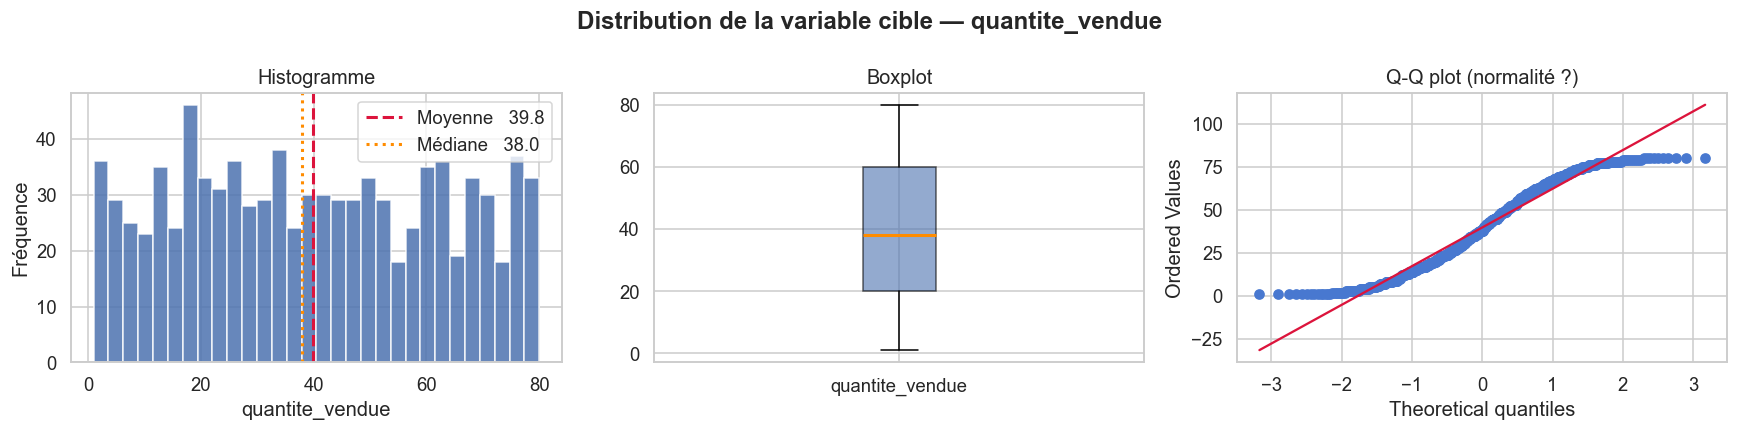

Asymétrie (skewness)  : 0.066
Aplatissement (kurtosis) : -1.179
Test de Shapiro-Wilk      : stat=0.9559, p=0.0000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribution de la variable cible — quantite_vendue', fontweight='bold')

# Histogramme
axes[0].hist(df['quantite_vendue'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['quantite_vendue'].mean(),   color='crimson',   lw=2, ls='--', label=f'Moyenne   {df["quantite_vendue"].mean():.1f}')
axes[0].axvline(df['quantite_vendue'].median(), color='darkorange', lw=2, ls=':',  label=f'Médiane   {df["quantite_vendue"].median():.1f}')
axes[0].set_xlabel('quantite_vendue'); axes[0].set_ylabel('Fréquence')
axes[0].set_title('Histogramme'); axes[0].legend()

# Boxplot
axes[1].boxplot(df['quantite_vendue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='darkorange', lw=2))
axes[1].set_xticklabels(['quantite_vendue'])
axes[1].set_title('Boxplot')

# Q-Q plot
stats.probplot(df['quantite_vendue'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot (normalité ?)')
axes[2].get_lines()[1].set_color('crimson')

plt.tight_layout()
plt.show()

print(f'Asymétrie (skewness)  : {df["quantite_vendue"].skew():.3f}')
print(f'Aplatissement (kurtosis) : {df["quantite_vendue"].kurtosis():.3f}')
print(f'Test de Shapiro-Wilk      : stat={stats.shapiro(df["quantite_vendue"])[0]:.4f}, p={stats.shapiro(df["quantite_vendue"])[1]:.4f}')

> **Interprétation :**
> - Le skewness = 0.066 confirme une distribution **quasi-symétrique** — bonne nouvelle pour la régression linéaire.
> - Le test de Shapiro-Wilk (p = 0.000) **rejette** l'hypothèse de normalité stricte, comme attendu sur 900 observations ; le Q-Q plot montre toutefois que les déviations aux queues restent modérées.
> - Le kurtosis = −1.18 (platicurtique) indique une distribution **plus aplatie** qu'une gaussienne — les valeurs sont réparties de manière assez uniforme entre 1 et 80.
> - Pas d'outliers sur la cible — pas de transformation logarithmique requise a priori.


---
## 4. Distribution des variables numériques explicatives

On examine chaque variable X numérique : forme de la distribution, asymétrie
et détection des valeurs aberrantes par la règle IQR (± 1,5 × IQR).

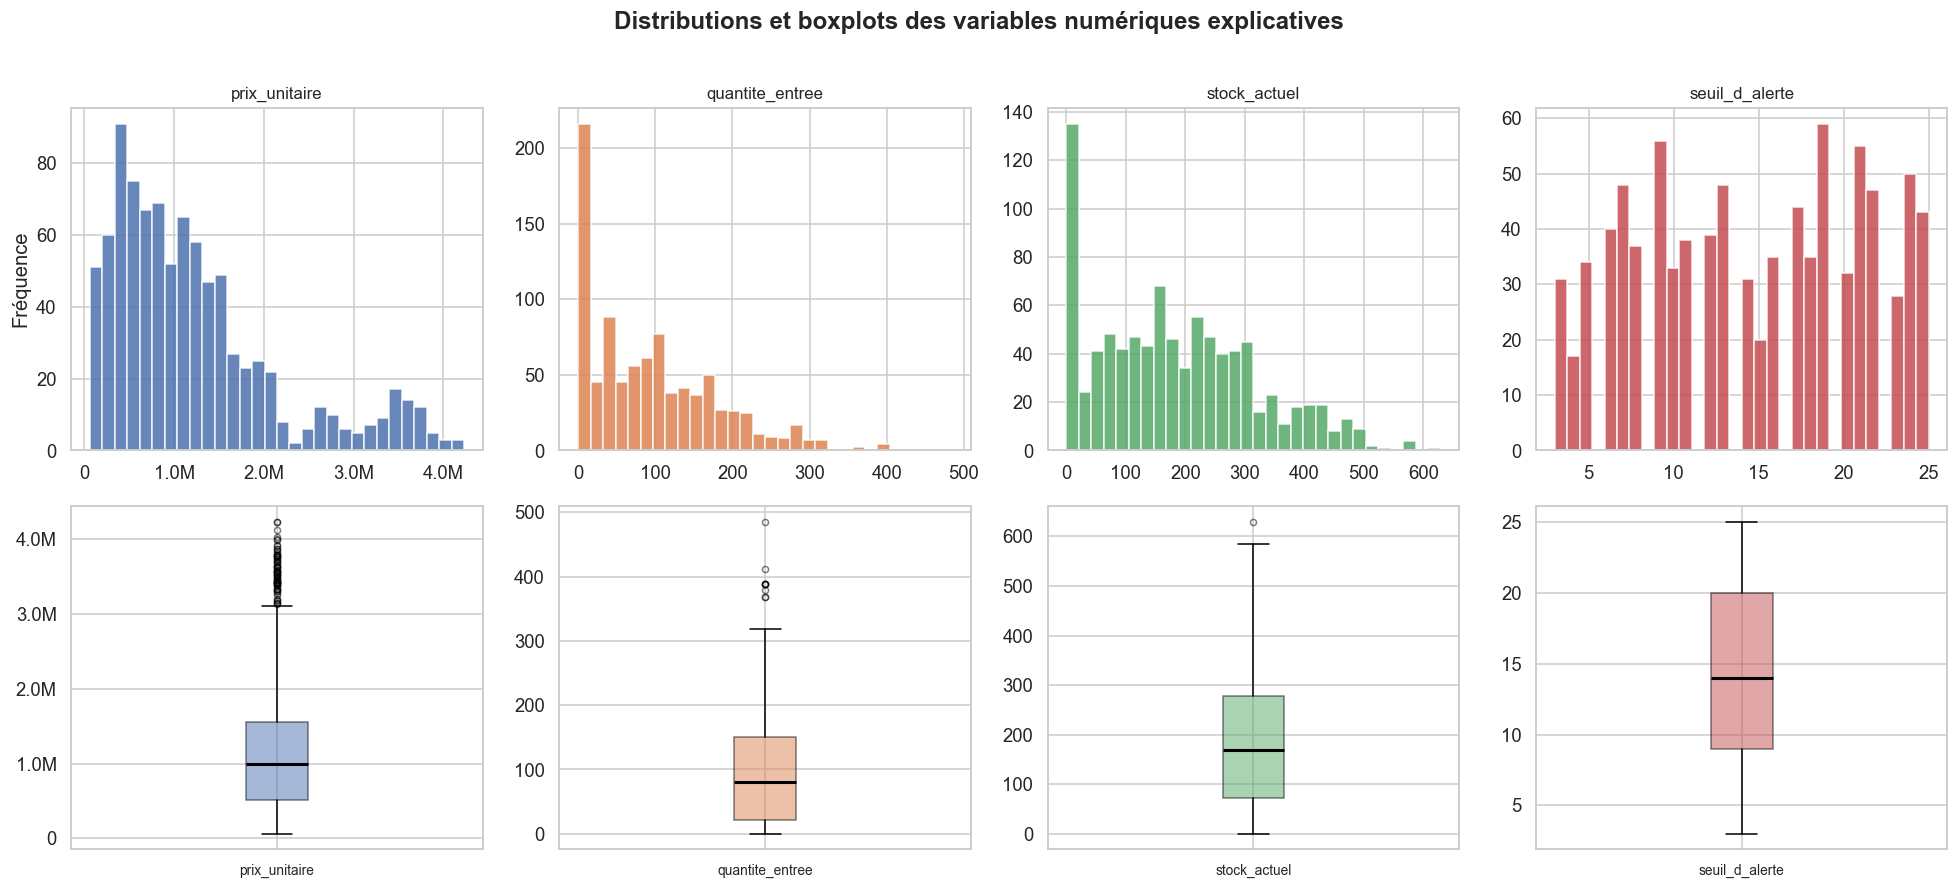

In [7]:
VARS_X_NUM = ['prix_unitaire', 'quantite_entree', 'stock_actuel', 'seuil_d_alerte']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions et boxplots des variables numériques explicatives',
             fontweight='bold', y=1.01)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (col, color) in enumerate(zip(VARS_X_NUM, colors)):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    # Histogramme
    ax_hist.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax_hist.set_title(col, fontsize=11)
    ax_hist.set_ylabel('Fréquence' if i == 0 else '')
    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x:,.0f}'))

    # Boxplot
    ax_box.boxplot(df[col], vert=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.5),
                   medianprops=dict(color='black', lw=2),
                   flierprops=dict(marker='o', markersize=4, alpha=0.5))
    ax_box.set_xticklabels([col], fontsize=9)
    ax_box.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [8]:
# ── Détection des outliers par méthode IQR ───────────────────────────────
print('=== Outliers détectés (méthode IQR : ± 1,5 × IQR) ===')
header = f"{'Variable':<25} {'Borne basse':>15} {'Borne haute':>15} {'Nb outliers':>12} {'% total':>8}"
print(header)
print('─' * 78)
for col in VARS_X_NUM + ['quantite_vendue']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n   = int(((df[col] < low) | (df[col] > high)).sum())
    pct = n / len(df) * 100
    print(f'{col:<25} {low:>15,.0f} {high:>15,.0f} {n:>12} {pct:>7.1f}%')


=== Outliers détectés (méthode IQR : ± 1,5 × IQR) ===
Variable                      Borne basse     Borne haute  Nb outliers  % total
──────────────────────────────────────────────────────────────────────────────
prix_unitaire                  -1,062,367       3,129,733           70     7.8%
quantite_entree                      -173             344            9     1.0%
stock_actuel                         -234             586            1     0.1%
seuil_d_alerte                         -8              36            0     0.0%
quantite_vendue                       -40             120            0     0.0%


> **Observations :**
> - `prix_unitaire` concentre le plus grand nombre d'outliers (≈ 7,8 %) : les produits haut de gamme (groupes électrogènes > 2 M Ar) constituent naturellement une queue de distribution à droite.
> - `quantite_vendue` **ne présente aucun outlier** — la cible est bien distribuée entre 1 et 80 unités.
> - Les outliers sur `prix_unitaire` seront gérés lors du préprocessing (notebook 04) : normalisation robuste ou winsorisation.

In [9]:
# ── Asymétrie (skewness) de chaque variable ──────────────────────────────
print('=== Skewness (asymétrie) ===')
skew = df[VARS_X_NUM + ['quantite_vendue']].skew().sort_values(ascending=False)
for col, val in skew.items():
    tag = '⚠ forte asymétrie' if abs(val) > 1 else ('  asymétrie modérée' if abs(val) > 0.5 else '  distribution symétrique')
    print(f'  {col:<25} {val:>7.3f}  {tag}')

=== Skewness (asymétrie) ===
  prix_unitaire               1.268  ⚠ forte asymétrie
  quantite_entree             0.950    asymétrie modérée
  stock_actuel                0.488    distribution symétrique
  quantite_vendue             0.066    distribution symétrique
  seuil_d_alerte             -0.051    distribution symétrique


---
## 5. Analyse de la variable catégorielle — `categorie`

La variable `categorie` sera encodée (One-Hot Encoding) avant modélisation.
On s'assure ici qu'elle est équilibrée et qu'elle apporte une information discriminante
sur la variable cible.

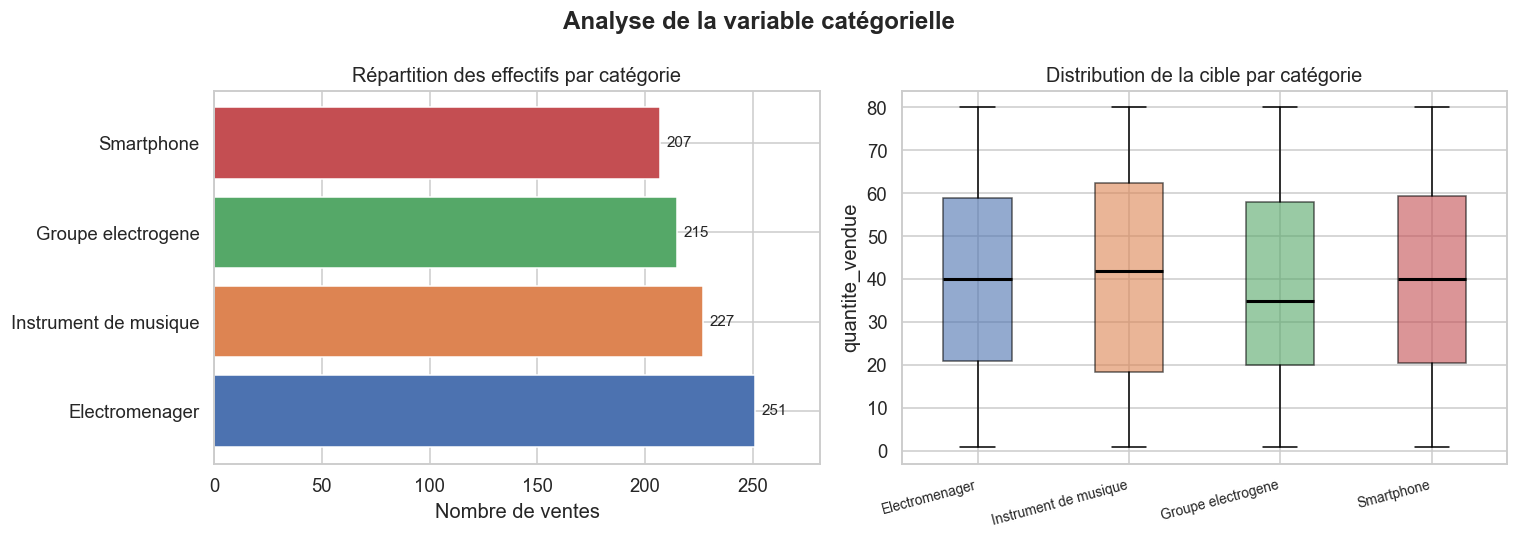

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse de la variable catégorielle', fontweight='bold')

# Répartition des effectifs
counts = df['categorie'].value_counts()
colors_list = list(PALETTE_CAT.values())
bars = axes[0].barh(counts.index, counts.values, color=colors_list)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=10)
axes[0].set_xlabel('Nombre de ventes')
axes[0].set_title('Répartition des effectifs par catégorie')
axes[0].set_xlim(0, counts.max() * 1.12)

# Boxplot quantite_vendue par catégorie
data_by_cat = [df[df['categorie'] == cat]['quantite_vendue'].values
               for cat in counts.index]
bp = axes[1].boxplot(data_by_cat, vert=True, patch_artist=True,
                     medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_xticklabels(counts.index, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('quantite_vendue')
axes[1].set_title('Distribution de la cible par catégorie')

plt.tight_layout()
plt.show()

In [11]:
# ── Statistiques de la cible par catégorie ───────────────────────────────
print('=== quantite_vendue par catégorie ===')
stats_cat = df.groupby('categorie')['quantite_vendue'].agg(
    count='count', moyenne='mean', mediane='median',
    ecart_type='std', min='min', max='max'
).round(2)
display(stats_cat)

=== quantite_vendue par catégorie ===


,count,moyenne,mediane,ecart_type,min,max
categorie,,,,,,
Electromenager,251,40.30,40.00,22.93,1,80
Groupe electrogene,215,38.31,35.00,21.52,1,80
Instrument de musique,227,40.68,42.00,24.46,1,80
Smartphone,207,39.92,40.00,22.72,1,80


> **Interprétation :**
> - Les quatre catégories sont **bien équilibrées** (207 à 251 ventes chacune) — pas de déséquilibre de classe.
> - Les distributions de `quantite_vendue` par catégorie sont similaires → `categorie` seule discrimine peu la cible.
> - Ce résultat confirme qu'un encodage simple suffira (pas de target encoding nécessaire).

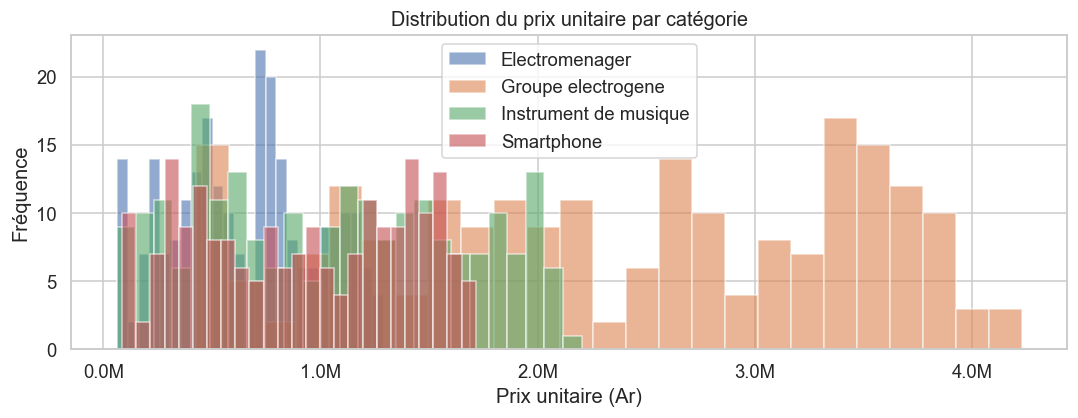

Prix moyen par catégorie :
categorie
Electromenager             650,235 Ar
Groupe electrogene       2,350,757 Ar
Instrument de musique    1,050,574 Ar
Smartphone                 916,984 Ar


In [12]:
# ── Prix unitaire par catégorie (ordre de grandeur différent) ────────────
fig, ax = plt.subplots(figsize=(10, 4))
for cat, color in PALETTE_CAT.items():
    subset = df[df['categorie'] == cat]['prix_unitaire']
    ax.hist(subset, bins=25, alpha=0.6, label=cat, color=color, edgecolor='white')
ax.set_xlabel('Prix unitaire (Ar)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du prix unitaire par catégorie')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

print('Prix moyen par catégorie :')
print(df.groupby('categorie')['prix_unitaire'].mean().apply(lambda x: f'{x:,.0f} Ar').to_string())

---
## 6. Matrice de corrélation

La matrice de corrélation de Pearson révèle les relations linéaires entre toutes
les variables numériques. C'est un outil essentiel pour :
- identifier les variables explicatives les plus corrélées avec la **cible** (`quantite_vendue`)
- détecter une éventuelle **multicolinéarité** entre les prédicteurs

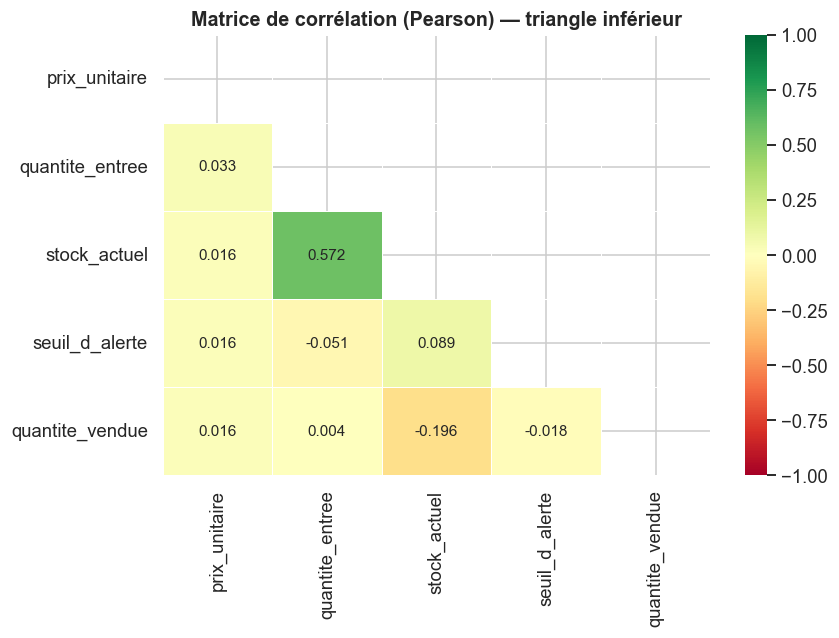

In [13]:
corr = df[VARS_X_NUM + ['quantite_vendue']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Masque triangle supérieur
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Matrice de corrélation (Pearson) — triangle inférieur', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Corrélations spécifiques avec la cible ───────────────────────────────
print('=== Corrélations avec quantite_vendue (triées) ===')
corr_cible = corr['quantite_vendue'].drop('quantite_vendue').sort_values(key=abs, ascending=False)
for var, val in corr_cible.items():
    absval = abs(val)
    if absval > 0.5:
        force = 'forte'
    elif absval > 0.3:
        force = 'modérée'
    elif absval > 0.1:
        force = 'notable'
    else:
        force = 'très faible'
    print(f'  {var:<25} r = {val:>7.3f}   corrélation {force}')


=== Corrélations avec quantite_vendue (triées) ===
  stock_actuel              r =  -0.196   corrélation notable
  seuil_d_alerte            r =  -0.018   corrélation très faible
  prix_unitaire             r =   0.016   corrélation très faible
  quantite_entree           r =   0.004   corrélation très faible


> **Interprétation :**
> - `stock_actuel` présente la corrélation linéaire la plus marquée avec `quantite_vendue` (r ≈ −0.20) : plus le stock est élevé, moins on vend — logique de saturation.
> - Les autres corrélations linéaires sont faibles. Cela ne signifie pas qu'il n'y a **pas de relation** — KNN capturera les relations non-linéaires.
> - La multicolinéarité entre prédicteurs est quasi nulle — pas de problème pour la régression linéaire.
>
> ⚠ La faiblesse des corrélations de Pearson suggère que les relations sont **non-linéaires** : KNN est un bon choix complémentaire.

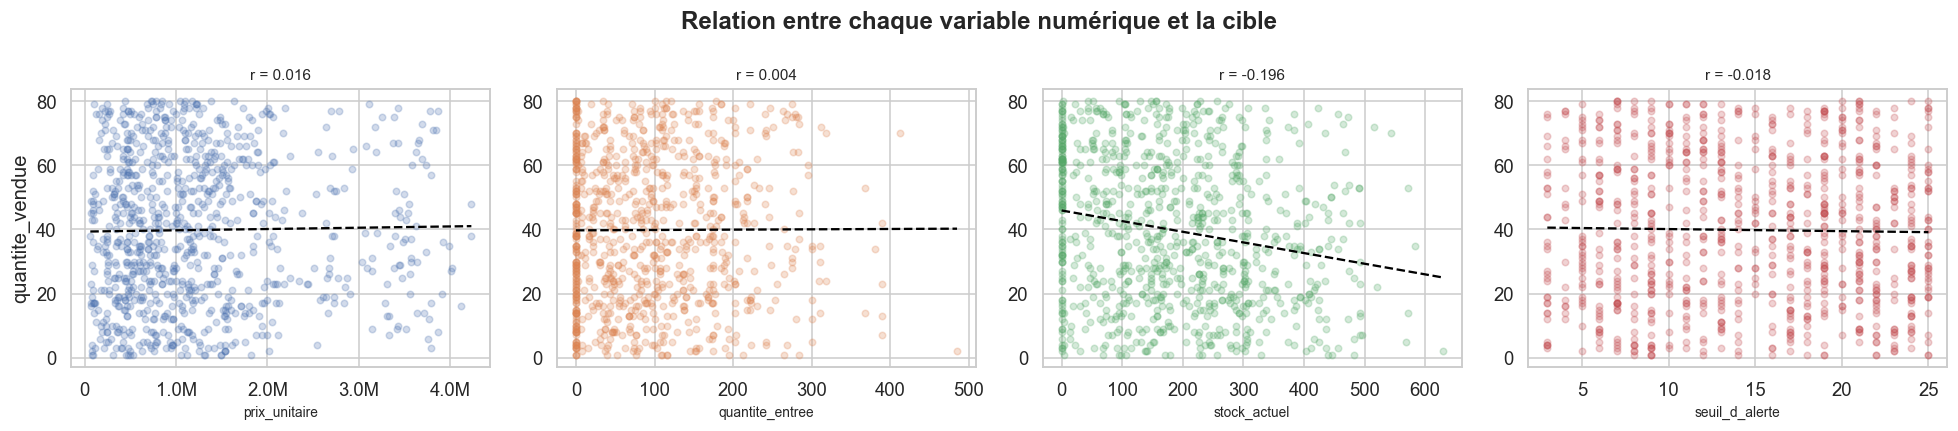

In [15]:
# ── Scatter plots : variables X vs cible ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Relation entre chaque variable numérique et la cible', fontweight='bold')

for i, (col, color) in enumerate(zip(VARS_X_NUM, colors)):
    axes[i].scatter(df[col], df['quantite_vendue'],
                    alpha=0.25, s=18, color=color)
    # Droite de régression
    m, b = np.polyfit(df[col], df['quantite_vendue'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='black', lw=1.5, ls='--')
    r = df[col].corr(df['quantite_vendue'])
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('quantite_vendue' if i == 0 else '')
    axes[i].set_title(f'r = {r:.3f}', fontsize=10)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else f'{x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 7. Analyse temporelle des ventes

La colonne `date` n'est pas une variable d'entrée des modèles, mais elle permet
de détecter des **tendances**, **saisonnalités** ou **anomalies** dans les données.

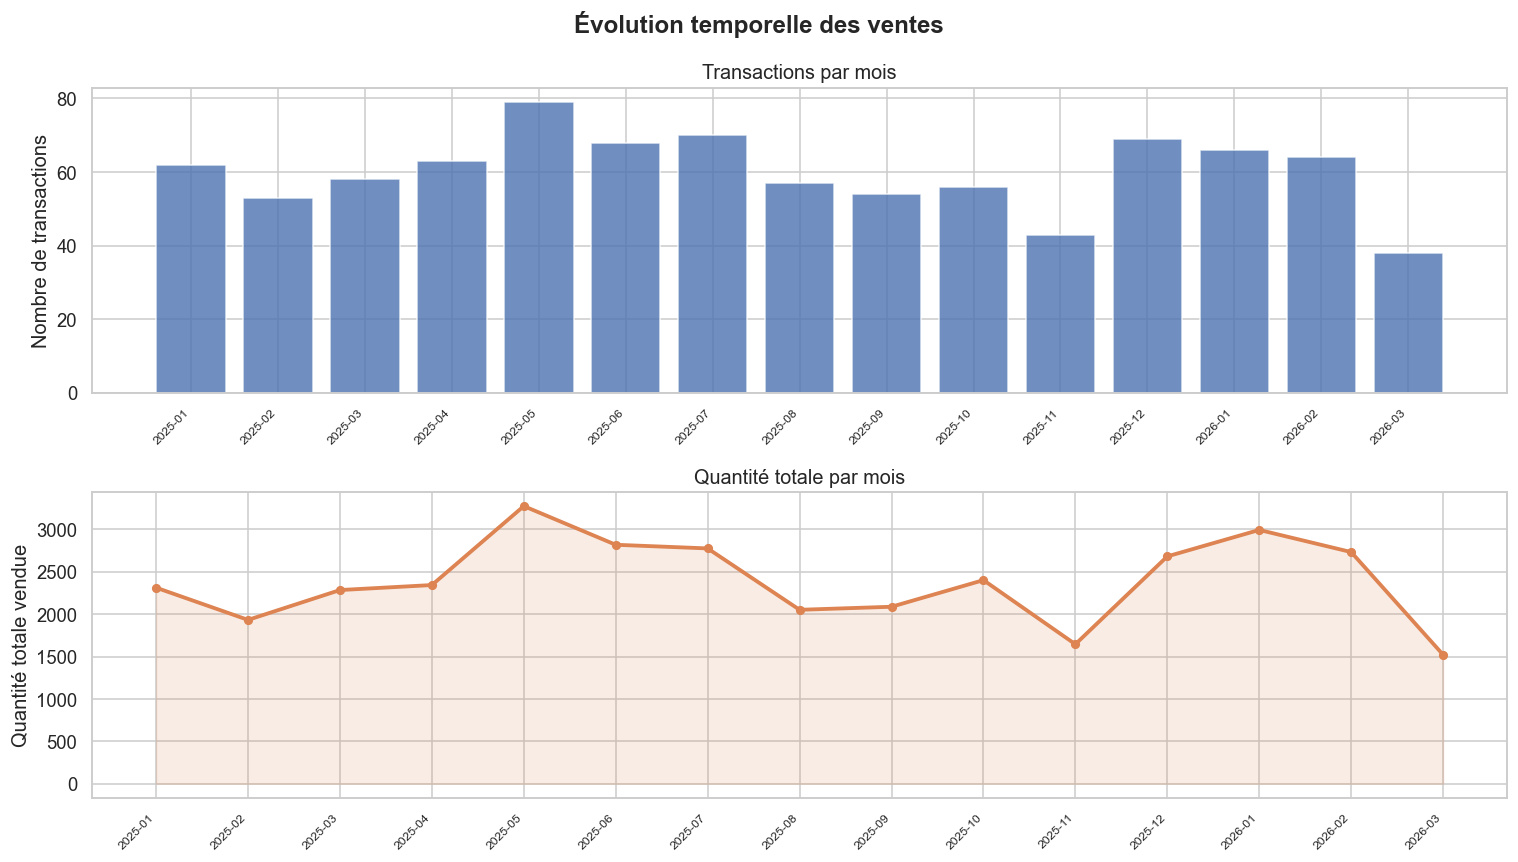

In [16]:
df_time = df.copy()
df_time['mois']    = df_time['date'].dt.to_period('M')
df_time['semaine'] = df_time['date'].dt.to_period('W')

# Agrégation mensuelle
ventes_mois = df_time.groupby('mois').agg(
    nb_transactions=('quantite_vendue', 'count'),
    total_vendu=('quantite_vendue', 'sum'),
    moy_vendu=('quantite_vendue', 'mean')
).reset_index()
ventes_mois['mois_str'] = ventes_mois['mois'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Évolution temporelle des ventes', fontweight='bold')

# Nb de transactions
axes[0].bar(range(len(ventes_mois)), ventes_mois['nb_transactions'],
            color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(len(ventes_mois)))
axes[0].set_xticklabels(ventes_mois['mois_str'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_title('Transactions par mois')

# Quantité totale vendue
axes[1].plot(range(len(ventes_mois)), ventes_mois['total_vendu'],
             color='#DD8452', lw=2.5, marker='o', ms=5)
axes[1].fill_between(range(len(ventes_mois)), ventes_mois['total_vendu'],
                     alpha=0.15, color='#DD8452')
axes[1].set_xticks(range(len(ventes_mois)))
axes[1].set_xticklabels(ventes_mois['mois_str'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Quantité totale vendue')
axes[1].set_title('Quantité totale par mois')

plt.tight_layout()
plt.show()

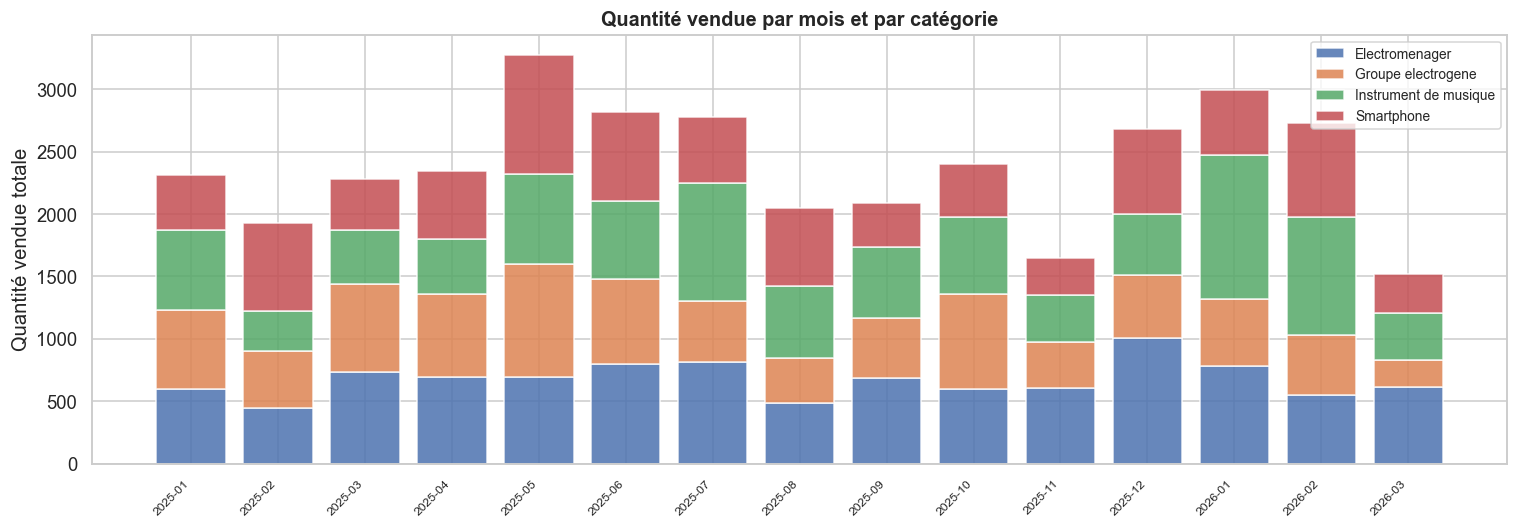

In [17]:
# ── Répartition des ventes par catégorie et par mois ─────────────────────
pivot = df_time.groupby(['mois', 'categorie'])['quantite_vendue'].sum().unstack(fill_value=0)
pivot.index = pivot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(len(pivot))
for cat, color in PALETTE_CAT.items():
    if cat in pivot.columns:
        ax.bar(range(len(pivot)), pivot[cat], bottom=bottom,
               label=cat, color=color, alpha=0.85, edgecolor='white')
        bottom += pivot[cat].values

ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Quantité vendue totale')
ax.set_title('Quantité vendue par mois et par catégorie', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Bilan de l'analyse exploratoire

### Récapitulatif des observations clés

| Aspect | Observation | Impact sur la modélisation |
|---|---|---|
| **Taille du dataset** | 900 lignes × 9 colonnes | Suffisant pour régression linéaire et KNN |
| **Valeurs manquantes** | Aucune (traitées en notebook 02) | Aucune imputation supplémentaire requise |
| **Doublons** | Aucun | Jeu de données propre ✓ |
| **Cible Y** | Quasi-symétrique, skewness ≈ 0 | Pas de transformation requise |
| **`prix_unitaire`** | Forte asymétrie droite (skewness ≈ 1.27) | **Normalisation requise** (StandardScaler ou RobustScaler) |
| **`quantite_entree`** | Asymétrie modérée, 9 outliers | Normalisation recommandée |
| **`categorie`** | 4 catégories équilibrées | **One-Hot Encoding** (drop_first=True pour régression linéaire) |
| **Corrélations** | Faibles (r < 0.25) sauf `stock_actuel` (r ≈ −0.20) | KNN pertinent pour relations non-linéaires |
| **Multicolinéarité** | Quasi-absente entre prédicteurs | Régression linéaire non pénalisée acceptable |
| **Tendance temporelle** | `date` non utilisée comme feature | À exclure du dataset de modélisation |

### Décisions pour le notebook 04 (Préprocessing)

1. **Exclure** les colonnes `date`, `reference`, `designation` (identifiants, pas de prédicteurs)
2. **One-Hot Encoding** de `categorie` (4 modalités → 3 dummies avec `drop='first'`)
3. **StandardScaler** sur toutes les variables numériques (améliore KNN et régression linéaire)
4. **Split train/test** : 80 % / 20 % avec `random_state=42` et `shuffle=True`

---
*Prochaine étape → `04_preprocessing_et_modelisation.ipynb`*

In [18]:
# ── Snapshot de la base pour le notebook suivant ────────────────────────
print('=== Résumé final de la base d\'apprentissage ===')
print(f'  Dimensions          : {df.shape}')
print(f'  Période             : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Catégories          : {sorted(df["categorie"].unique())}')
print(f'  Cible Y (min/max)   : {df["quantite_vendue"].min()} / {df["quantite_vendue"].max()}')
print(f'  Valeurs manquantes  : {df.isna().sum().sum()}')
print()
print('Base prête pour le préprocessing et la modélisation ✓')

=== Résumé final de la base d'apprentissage ===
  Dimensions          : (900, 9)
  Période             : 2025-01-01 → 2026-03-20
  Catégories          : ['Electromenager', 'Groupe electrogene', 'Instrument de musique', 'Smartphone']
  Cible Y (min/max)   : 1 / 80
  Valeurs manquantes  : 0

Base prête pour le préprocessing et la modélisation ✓
